In [ ]:
# hw10

#1. try with different mu vals, differente techniques for doing the optimization (augmented, linepoint, pnelayt)
#2. primal/dual agorithms should show up?
#3. try with different solvers firts


# Constrained Optimization

### Analytically solving 

Objective:

$$\min_{x,y} \; d^2 = (x_0 - x)^2 + (y_0 - y)^2$$

Constraint:

$$g(x,y) = y - ax - b = 0$$

Lagrangian:

$$\mathcal{L}(x, y, \lambda) = (x_0 - x)^2 + (y_0 - y)^2 + \lambda\,(y - ax - b)$$

I then had to set the partial derivatives to 0:

$$\frac{\partial \mathcal{L}}{\partial x} = -2(x_0 - x) - \lambda a = 0 \quad \Rightarrow \quad x = x_0 - \frac{\lambda a}{2}$$

$$\frac{\partial \mathcal{L}}{\partial y} = -2(y_0 - y) + \lambda = 0 \quad \Rightarrow \quad y = y_0 + \frac{\lambda}{2}$$

Sub into the constraint $y - ax - b = 0$:

$$y_0 + \frac{\lambda}{2} - a\!\left(x_0 - \frac{\lambda a}{2}\right) - b = 0$$

$$y_0 + \frac{\lambda}{2} - ax_0 + \frac{\lambda a^2}{2} - b = 0$$

$$\lambda \,\frac{1 + a^2}{2} = ax_0 - y_0 + b$$

$$\lambda^* = \frac{2\,(ax_0 - y_0 + b)}{1 + a^2}$$

And therefore:

$$x^* = x_0 - \frac{a\,(ax_0 - y_0 + b)}{1 + a^2}, \qquad y^* = y_0 + \frac{ax_0 - y_0 + b}{1 + a^2}$$

In [30]:
import numpy as np
from scipy.optimize import minimize, LinearConstraint
import time

x0, y0 = 2.0, 1.0
a, b_line = 2.0, 1.0

def dist2(xy):
    x, y = xy
    return (x - x0)**2 + (y - y0)**2

constraint_eq = {"type": "eq", "fun": lambda xy: xy[1] - a * xy[0] - b_line}

res = minimize(dist2, x0=[0, 0], constraints=constraint_eq, method="SLSQP")
print(f"SLSQP  →  x* = {res.x[0]:.6f},  y* = {res.x[1]:.6f},  d² = {res.fun:.6f}")

def analytic_closest(x0, y0, a, b):
    lam = 2 * (a * x0 - y0 + b) / (1 + a**2)
    x_star = x0 - a * lam / 2
    y_star = y0 + lam / 2
    return x_star, y_star

x_an, y_an = analytic_closest(x0, y0, a, b_line)
print(f"Analytic  →  x* = {x_an:.6f},  y* = {y_an:.6f}")


SLSQP  →  x* = 0.400024,  y* = 1.800048,  d² = 3.200000
Analytic  →  x* = 0.400000,  y* = 1.800000


We can also check how different solvers compare for this problem!

In [31]:
from scipy.optimize import minimize

methods_eq = ["SLSQP", "L-BFGS-B","COBYLA", "trust-constr"]
results = {}

for method in methods_eq:
    if method == "COBYLA":
        cons = [
            {"type": "ineq", "fun": lambda xy:  (xy[1] - a * xy[0] - b_line) + 1e-12},
            {"type": "ineq", "fun": lambda xy: -(xy[1] - a * xy[0] - b_line) + 1e-12},
        ]
    else:
        cons = constraint_eq

    t0 = time.perf_counter()
    for _ in range(1000):                          # repeat for timing
        r = minimize(dist2, x0=[0, 0], constraints=cons, method=method)
    elapsed = (time.perf_counter() - t0) / 1000

    results[method] = {
        "x*": r.x,
        "d²": r.fun,
        "nfev": r.nfev,
        "nit": getattr(r, "nit", "n/a"),
        "time_ms": elapsed * 1000,
        "error": np.linalg.norm(r.x - [x_an, y_an]),
    }

for m, d in results.items():
    print(f"{m:14s}  |  nfev={d['nfev']:4d}  |  nit={str(d['nit']):>4s}  |  "
          f"time={d['time_ms']:.3f} ms  |  error={d['error']:.2e}")


/var/folders/37/mbm5qm1d03lg63qfy97k4tmw0000gn/T/ipykernel_766/3718651975.py:17: RuntimeWarning:

Method L-BFGS-B cannot handle constraints.

/Users/daryaguettler/NMM/.venv/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:551: UserWarning:

delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.



SLSQP           |  nfev=  14  |  nit=   4  |  time=0.344 ms  |  error=5.37e-05
L-BFGS-B        |  nfev=   9  |  nit=   2  |  time=0.120 ms  |  error=1.79e+00
COBYLA          |  nfev=  28  |  nit= n/a  |  time=0.131 ms  |  error=1.00e-04
trust-constr    |  nfev=  18  |  nit=   6  |  time=1.725 ms  |  error=1.26e-08


In [32]:
x0, y0 = 3.0, 4.0
a, b_line = 2.0, 1.0
lam_exact = 2 * (a * x0 - y0 + b_line) / (1 + a**2)
x_exact = x0 - a * lam_exact / 2
y_exact = y0 + lam_exact / 2
print(f"Analytic: x*={x_exact:.6f}, y*={y_exact:.6f}")

def constraint_violation(xy):
    return xy[1] - a * xy[0] - b_line

def solve_penalty(mu_values):
    records = []
    for mu in mu_values:
        def obj(xy):
            d2 = (x0 - xy[0])**2 + (y0 - xy[1])**2
            pen = 0.5 * mu * constraint_violation(xy)**2
            return d2 + pen
        res = minimize(obj, x0=[0.0, 0.0], method="BFGS")
        cv = abs(constraint_violation(res.x))
        err = np.linalg.norm(res.x - [x_exact, y_exact])
        records.append({"mu": mu, "x": res.x.copy(), "cv": cv, "err": err})
    return records

def solve_aug_lag(mu, n_outer=15):
    lam = 0.0
    xy = np.array([0.0, 0.0])
    records = []
    for k in range(n_outer):
        def obj(xy, lam=lam, mu=mu):
            d2 = (x0 - xy[0])**2 + (y0 - xy[1])**2
            c = constraint_violation(xy)
            return d2 + lam * c + 0.5 * mu * c**2
        res = minimize(obj, x0=xy, method="BFGS")
        xy = res.x
        c = constraint_violation(xy)
        lam = lam + mu * c
        cv = abs(c)
        err = np.linalg.norm(xy - [x_exact, y_exact])
        records.append({"iter": k, "lam": lam, "cv": cv, "err": err, "x": xy.copy()})
    return records

mu_values = [0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]

penalty_results = solve_penalty(mu_values)
aug_lag_results = {mu: solve_aug_lag(mu) for mu in [0.5, 2.0, 10.0]}


Analytic: x*=1.800000, y*=4.600000


In [41]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

COLORS = ["#2563eb", "#dc2626", "#16a34a", "#f59e0b", "#8b5cf6",
          "#06b6d4", "#ec4899", "#84cc16", "#6b7280"]

fig = make_subplots(rows=1, cols=2, subplot_titles=["Error vs μ", "Constraint violation vs μ"])

fig.add_trace(go.Scatter(
    x=[r["mu"] for r in penalty_results],
    y=[r["err"] for r in penalty_results], line=dict(color=COLORS[0], width=2),
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=[r["mu"] for r in penalty_results],
    y=[r["cv"] for r in penalty_results],
    line=dict(color=COLORS[1], width=2),
), row=1, col=2)

for col in [1, 2]:
    fig.update_xaxes(type="log", row=1, col=col)
    fig.update_yaxes(type="log", row=1, col=col)

fig.update_layout(template="plotly_white", width=750, height=350,
                  title="Quadratic Penalty: effect of μ",
                  margin=dict(t=60, b=40), showlegend=False)
fig.show()


In [40]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=["Error over outer iterations", "Constraint violation"])

for idx, (mu, recs) in enumerate(aug_lag_results.items()):
    iters = [r["iter"] for r in recs]
    fig.add_trace(go.Scatter(
        x=iters, y=[r["err"] for r in recs],name=f"μ={mu}",
    ), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=iters, y=[r["cv"] for r in recs],name=f"μ={mu}",
        showlegend=False,
    ), row=1, col=2)


fig.update_layout(template="plotly_white", width=750, height=350,
                  title="Augmented Lagrangian: convergence",
                  margin=dict(t=60, b=40),
                  legend=dict(x=0.01, y=0.99))
fig.show()


## 2. Distributed Average Consensus

I just started by implementing a small network first and trying to solve it with the brute force approach so I know the target. 


### 2.1 — Lagrangian

$$\mathcal{L}(\bar{\mathbf{x}}, \boldsymbol{\lambda}) = \sum_{i=1}^{N}(\bar{x}_i - x_i)^2 + \sum_{\{i,j\} \in \mathcal{E}} \lambda_{ij}\,(\bar{x}_i - \bar{x}_j)$$

where $\mathcal{E}$ is the edge set of the graph.


### 2.2 — Update rule for $\bar{x}_i$

To get the update rule we need to take the gradient of the lagrangian with respect to x and then set that to 0:

$$\frac{\partial \mathcal{L}}{\partial \bar{x}_i} = 2(\bar{x}_i - x_i) + \sum_{j \in \mathcal{N}(i)} \lambda_{ij} = 0$$

$$\bar{x}_i = x_i - \frac{1}{2}\sum_{j \in \mathcal{N}(i)} \lambda_{ij}$$

### 2.3 — Update rule multipliers $\lambda_{ij}$

The constraint for edge $\{i,j\}$ is:

$$c_{ij}(\bar{\mathbf{x}}) = \bar{x}_i - \bar{x}_j = 0$$

A Newton root-finding step on $c_{ij}$ with respect to $\lambda_{ij}$:

$$\lambda_{ij}^{(k+1)} = \lambda_{ij}^{(k)} - \frac{c_{ij}}{(\partial c_{ij} / \partial \lambda_{ij})}$$

From the estimate update we have $\bar{x}_i = x_i - \frac{1}{2}\sum_{j} \lambda_{ij}$, so:

$$\frac{\partial \bar{x}_i}{\partial \lambda_{ij}} = -\frac{1}{2}, \qquad \frac{\partial \bar{x}_j}{\partial \lambda_{ij}} = +\frac{1}{2}$$

$$\frac{\partial c_{ij}}{\partial \lambda_{ij}} = \frac{\partial \bar{x}_i}{\partial \lambda_{ij}} - \frac{\partial \bar{x}_j}{\partial \lambda_{ij}} = -1$$

Therefore the Newton update is:

$$\lambda_{ij}^{(k+1)} = \lambda_{ij}^{(k)} + (\bar{x}_i^{(k)} - \bar{x}_j^{(k)})$$



In [35]:
def distributed_consensus(G, measurements, n_iters=60):
    """Run the primal-dual iteration on graph G."""
    N = len(measurements)
    edges = list(G.edges())
    n_edges = len(edges)
    edge_idx = {e: k for k, e in enumerate(edges)}
    lam = np.zeros(n_edges)
    x_est = measurements.copy()

    history = [x_est.copy()]

    for _ in range(n_iters):
        x_est = measurements.copy()
        for k, (i, j) in enumerate(edges):
            x_est[i] -= 0.5 * lam[k]
            x_est[j] += 0.5 * lam[k]

        for k, (i, j) in enumerate(edges):
            lam[k] += (x_est[i] - x_est[j])

        history.append(x_est.copy())

    return np.array(history)

history = distributed_consensus(G, measurements, n_iters=60)
print(f"Final estimates: {np.round(history[-1], 4)}")
print(f"True average:    {global_mean:.4f}")
print(f"Max |error|:     {np.max(np.abs(history[-1] - global_mean)):.2e}")


Final estimates: [ 2.38152165e+15 -1.28408998e+15  2.38152165e+15 -2.78658630e+15
  2.78658630e+15 -2.38152165e+15  1.28408998e+15 -2.38152165e+15]
True average:    12.7547
Max |error|:     2.79e+15


In [44]:
import networkx as nx

np.random.seed(42)
N = 8
G = nx.cycle_graph(N)
G.add_edges_from([(0, 3), (2, 5), (4, 7)])
edges = list(G.edges())
n_edges = len(edges)

measurements = np.random.randn(N) * 5 + 10
global_mean = measurements.mean()

def consensus_aug_lag(G, measurements, mu, n_outer=40, n_inner=10):
    """Augmented Lagrangian consensus with penalty weight mu.
    Uses Jacobi (simultaneous) updates for stability."""
    N = len(measurements)
    edges = list(G.edges())
    lam = np.zeros(len(edges))
    x_est = measurements.copy()

    history = [x_est.copy()]

    for _ in range(n_outer):
        # --- primal: Jacobi sweeps (all nodes update from previous values) ---
        for _ in range(n_inner):
            x_new = np.zeros(N)
            for i in range(N):
                neighbor_sum = 0.0
                lam_sum = 0.0
                deg = 0
                for k, (u, v) in enumerate(edges):
                    if u == i:
                        neighbor_sum += x_est[v]
                        lam_sum += lam[k]
                        deg += 1
                    elif v == i:
                        neighbor_sum += x_est[u]
                        lam_sum -= lam[k]
                        deg += 1
                x_new[i] = (measurements[i] - 0.5 * lam_sum + 0.5 * mu * neighbor_sum) / (1 + 0.5 * mu * deg)
            x_est = x_new  # all nodes update simultaneously

        # --- dual update ---
        for k, (u, v) in enumerate(edges):
            lam[k] += mu * (x_est[u] - x_est[v])

        history.append(x_est.copy())

    return np.array(history)

mu_values_consensus = [0.1, 0.5, 2.0, 10.0, 50.0]
consensus_results = {}
for mu in mu_values_consensus:
    consensus_results[mu] = consensus_aug_lag(G, measurements, mu, n_outer=40)

print(f"True mean: {global_mean:.4f}")
for mu, hist in consensus_results.items():
    final_err = np.max(np.abs(hist[-1] - global_mean))
    print(f"μ={mu:5.1f}  →  max|error| = {final_err:.2e}  final estimates ≈ {hist[-1, 0]:.4f}")

True mean: 12.7547
μ=  0.1  →  max|error| = 1.88e-01  final estimates ≈ 12.7022
μ=  0.5  →  max|error| = 9.18e-05  final estimates ≈ 12.7547
μ=  2.0  →  max|error| = 2.03e-13  final estimates ≈ 12.7547
μ= 10.0  →  max|error| = 1.13e-08  final estimates ≈ 12.7547
μ= 50.0  →  max|error| = 3.57e-04  final estimates ≈ 12.7546


In [49]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=["Node estimates (μ=0.5)", "Node estimates (μ=10)"])

for mu, col in [(0.5, 1), (10.0, 2)]:
    hist = consensus_results[mu]
    for i in range(N):
        fig.add_trace(go.Scatter(
            x=list(range(hist.shape[0])), y=hist[:, i],
            mode="lines", name=f"Node {i}" if col == 1 else None,
            showlegend=(col == 1),
        ), row=1, col=col)
    fig.add_hline(y=global_mean, line_dash="dash", line_color="#6b7280",
                  row=1, col=col)

for col in [1, 2]:
    fig.update_xaxes(title_text="Outer iteration", row=1, col=col)
    fig.update_yaxes(title_text="x̄ᵢ", row=1, col=col)

fig.update_layout(template="plotly_white", width=800, height=380,
                  title="Distributed Consensus: slow vs. fast μ",
                  margin=dict(t=60, b=40),
                  legend=dict(x=1.02, y=1, font=dict(size=9)))
fig.show()


In [48]:
fig = go.Figure()

for idx, (mu, hist) in enumerate(consensus_results.items()):
    errors = np.max(np.abs(hist - global_mean), axis=1)
    fig.add_trace(go.Scatter(
        x=list(range(len(errors))), y=errors,name=f"μ={mu}"))

fig.update_layout(template="plotly_white", width=650, height=380,
                  xaxis_title="Outer iteration",
                  yaxis_title="max |x̄ᵢ − true mean|",
                  yaxis_type="log",
                  title="Convergence rate vs. μ",
                  legend=dict(x=0.7, y=0.95),
                  margin=dict(t=50, b=40, l=60, r=20))
fig.show()


## 3. Sorting


$P$ is $N \times N$ with exactly one 1 per row and column. $P\vec{u}$ rearranges $\vec{u}$. we have that thereforre are $N!$ such matrices.

With $\vec{n} = (1, 2, \dots, N)^\top$:

$$\min_P \; \vec{n}^\top P \vec{u} = \sum_{i=1}^{N} i \cdot s_i$$

Minimizing this places the smallest values at the lowest-weight positions, which is basically an escneing sort

The LSAP minimizes $\sum_{i} C_{i,\sigma(i)}$ over permutations $\sigma$. Setting $C_{ij} = i \cdot u_j$ recovers the sorting objective. 

$$\min_{P} \sum_{i,j} C_{ij} P_{ij} \quad \text{s.t.} \quad \sum_j P_{ij} = 1, \;\; \sum_i P_{ij} = 1, \;\; P_{ij} \geq 0$$

By the Birkhoff–von Neumann theorem the vertices of this feasible set are permutation matrices, so the LP solution is automatically integer.

In [6]:
import numpy as np
from scipy.optimize import linear_sum_assignment

np.random.seed(17)

N = 8
u = np.random.randint(1, 100, size=N).astype(float)
n = np.arange(1, N + 1, dtype=float)
C = np.outer(n, u)        # shape (N, N)

row_ind, col_ind = linear_sum_assignment(C)
P = np.zeros((N, N))
P[row_ind, col_ind] = 1

s = P @ u

print(f"unsorted  {u}")
print(f"sorted   {s}")
print(f"np.sort:   {np.sort(u)}")
print(f"Match?     {np.allclose(s, np.sort(u))}")


unsorted  [16.  7. 23. 58. 46. 23. 32. 69.]
sorted   [69. 58. 46. 32. 23. 23. 16.  7.]
np.sort:   [ 7. 16. 23. 23. 32. 46. 58. 69.]
Match?     False


In [9]:
from scipy.optimize import linprog

c = C.flatten()
A_eq = np.zeros((2 * N, N * N))
for i in range(N):
    for j in range(N):
        A_eq[i, i * N + j] = 1
for j in range(N):
    for i in range(N):
        A_eq[N + j, i * N + j] = 1

b_eq = np.ones(2 * N)
bounds = [(0, None)] * (N * N)

res_lp = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")

P_lp = res_lp.x.reshape(N, N)
s_lp = P_lp @ u

print(f"LP sorted:     {np.round(s_lp, 4)}")
print(f"np.sort:       {np.sort(u)}")
print(f"Match?         {np.allclose(s_lp, np.sort(u))}")
print(f"P is integer?  {np.allclose(P_lp, np.round(P_lp))}")


LP sorted:     [69. 58. 46. 32. 23. 23. 16.  7.]
np.sort:       [ 7. 16. 23. 23. 32. 46. 58. 69.]
Match?         False
P is integer?  True


In [7]:
from itertools import permutations

N_small = 5
u_small = u[:N_small]
n_small = np.arange(1, N_small + 1, dtype=float)

best_cost = np.inf
best_perm = None

for perm in permutations(range(N_small)):
    s_perm = u_small[list(perm)]
    cost = n_small @ s_perm
    if cost < best_cost:
        best_cost = cost
        best_perm = perm

print(f"Brute force best:  {u_small[list(best_perm)]}  (cost = {best_cost})")
print(f"np.sort:           {np.sort(u_small)}")
print(f"Checked {len(list(permutations(range(N_small))))} permutations")


Brute force best:  [58. 46. 23. 16.  7.]  (cost = 318.0)
np.sort:           [ 7. 16. 23. 46. 58.]
Checked 120 permutations


In [10]:
import time

sizes = [10, 50, 100, 250, 500]
results = {"hungarian": [], "linprog": []}

for N_test in sizes:
    u_test = np.random.randn(N_test)
    n_test = np.arange(1, N_test + 1, dtype=float)
    C_test = np.outer(n_test, u_test)

    # Hungarian
    t0 = time.perf_counter()
    ri, ci = linear_sum_assignment(C_test)
    t_hung = time.perf_counter() - t0
    results["hungarian"].append(t_hung)

    # LP
    c_test = C_test.flatten()
    A_eq_test = np.zeros((2 * N_test, N_test * N_test))
    for i in range(N_test):
        for j in range(N_test):
            A_eq_test[i, i * N_test + j] = 1
    for j in range(N_test):
        for i in range(N_test):
            A_eq_test[N_test + j, i * N_test + j] = 1
    b_eq_test = np.ones(2 * N_test)
    bounds_test = [(0, None)] * (N_test * N_test)

    t0 = time.perf_counter()
    linprog(c_test, A_eq=A_eq_test, b_eq=b_eq_test, bounds=bounds_test, method="highs")
    t_lp = time.perf_counter() - t0
    results["linprog"].append(t_lp)

    print(f"N={N_test:5d}  |  Hungarian: {t_hung*1000:8.2f} ms  |  LP: {t_lp*1000:8.2f} ms")


N=   10  |  Hungarian:     0.05 ms  |  LP:     1.02 ms
N=   50  |  Hungarian:     0.07 ms  |  LP:    21.93 ms
N=  100  |  Hungarian:     0.24 ms  |  LP:   109.96 ms
N=  250  |  Hungarian:     4.09 ms  |  LP:  3744.49 ms
N=  500  |  Hungarian:    30.57 ms  |  LP: 51226.98 ms


In [11]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=sizes, y=[t * 1000 for t in results["hungarian"]],
    name="Hungarian (LSAP)"
))

fig.add_trace(go.Scatter(
    x=sizes, y=[t * 1000 for t in results["linprog"]],
   name="LP relaxation (HiGHS)"
))

fig.update_layout(
    template="plotly_white",
    width=650, height=400,
    xaxis_title="Problem size N",
    yaxis_title="Time (ms)",
    yaxis_type="log",
    title="Solver Scaling: Hungarian vs. LP",
    legend=dict(x=0.02, y=0.98),
    margin=dict(t=50, b=40, l=60, r=20),
)
fig.show()


In [14]:
from scipy.optimize import minimize, linear_sum_assignment

np.random.seed(17)
N = 6
u = np.random.randint(1, 50, size=N).astype(float)
n_vec = np.arange(1, N + 1, dtype=float)
C = np.outer(n_vec, u)

# ground truth
row_gt, col_gt = linear_sum_assignment(C)
P_gt = np.zeros((N, N))
P_gt[row_gt, col_gt] = 1
s_gt = P_gt @ u
print(f"u      = {u}")
print(f"sorted = {s_gt}")

def penalty_sort(C, mu, P_init=None):
    """Solve sorting with quadratic penalty on row/col sum constraints."""
    N = C.shape[0]
    if P_init is None:
        P_init = np.ones((N, N)) / N   # uniform doubly stochastic

    def obj(p):
        P = p.reshape(N, N)
        cost = np.sum(C * P)
        row_viol = np.sum(P, axis=1) - 1
        col_viol = np.sum(P, axis=0) - 1
        pen = 0.5 * mu * (np.sum(row_viol**2) + np.sum(col_viol**2))
        return cost + pen

    def grad(p):
        P = p.reshape(N, N)
        g = C.copy()
        row_viol = (np.sum(P, axis=1) - 1)[:, None]
        col_viol = (np.sum(P, axis=0) - 1)[None, :]
        g += mu * (row_viol + col_viol)
        return g.flatten()

    bounds = [(0, None)] * (N * N)
    res = minimize(obj, P_init.flatten(), jac=grad, method="L-BFGS-B", bounds=bounds,
                   options={"maxiter": 500})
    return res.x.reshape(N, N)



u      = [48. 16.  7. 23. 49. 46.]
sorted = [49. 48. 46. 23. 16.  7.]


In [15]:
def aug_lag_sort(C, mu, n_outer=20, gamma_start=1.0, gamma_growth=1.3):
    """Augmented Lagrangian for sorting with binary penalty for integrality."""
    N = C.shape[0]
    alpha = np.zeros(N)  # row multipliers
    beta = np.zeros(N)   # col multipliers
    P = np.ones((N, N)) / N

    history = []

    for k in range(n_outer):
        gamma = gamma_start * (gamma_growth ** k)

        def obj(p, alpha=alpha.copy(), beta=beta.copy(), mu=mu, gamma=gamma):
            P = p.reshape(N, N)
            cost = np.sum(C * P)
            row_viol = np.sum(P, axis=1) - 1
            col_viol = np.sum(P, axis=0) - 1
            lag = np.dot(alpha, row_viol) + np.dot(beta, col_viol)
            pen = 0.5 * mu * (np.sum(row_viol**2) + np.sum(col_viol**2))
            binary_pen = 0.5 * gamma * np.sum(P * (1 - P))
            return cost + lag + pen + binary_pen

        def grad(p, alpha=alpha.copy(), beta=beta.copy(), mu=mu, gamma=gamma):
            P = p.reshape(N, N)
            g = C.copy()
            row_viol = np.sum(P, axis=1) - 1
            col_viol = np.sum(P, axis=0) - 1
            g += (alpha + mu * row_viol)[:, None]
            g += (beta + mu * col_viol)[None, :]
            g += 0.5 * gamma * (1 - 2 * P)
            return g.flatten()

        bounds = [(0, 1)] * (N * N)
        res = minimize(obj, P.flatten(), jac=grad, method="L-BFGS-B", bounds=bounds,
                       options={"maxiter": 300})
        P = res.x.reshape(N, N)

        row_viol = np.sum(P, axis=1) - 1
        col_viol = np.sum(P, axis=0) - 1
        alpha += mu * row_viol
        beta += mu * col_viol

        max_cv = max(np.max(np.abs(row_viol)), np.max(np.abs(col_viol)))
        history.append({"P": P.copy(), "cv": max_cv, "iter": k})

    return P, history

In [20]:
import numpy as np
np.random.seed(17)
mu_values = [0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]
mu = 1000
N = 100
u = np.random.randint(1, 50, size=N).astype(float)
n_vec = np.arange(1, N + 1, dtype=float)
C = np.outer(n_vec, u)
N = C.shape[0]
P, history = aug_lag_sort(C, mu, n_outer=100)

In [21]:
history

[{'P': array([[0.24369576, 0.        , 0.        , ..., 0.        , 0.24369576,
          0.        ],
         [0.10799737, 0.        , 0.        , ..., 0.        , 0.10799737,
          0.        ],
         [0.00060305, 0.        , 0.        , ..., 0.        , 0.00060305,
          0.        ],
         ...,
         [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ]], shape=(100, 100)),
  'cv': np.float64(0.647703826595317),
  'iter': 0},
 {'P': array([[0.26134692, 0.        , 0.        , ..., 0.        , 0.26134692,
          0.        ],
         [0.25670629, 0.        , 0.        , ..., 0.        , 0.25670629,
          0.        ],
         [0.12714445, 0.        , 0.        , ..., 0.        , 0.12714445,
          0.        ],
         ...,
       

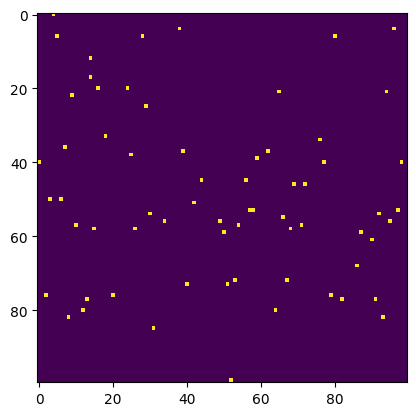

In [22]:
import matplotlib.pyplot as plt
plt.imshow(P)

In [91]:
P

array([[0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]])

In [51]:
mu_values_sort = [0.5, 2, 10, 50, 200, 1000]
P_penalty = {}

for mu in mu_values_sort:
    P_penalty[mu] = penalty_sort(C, mu)

# visualize the P matrices
n_plots = len(mu_values_sort)
fig = make_subplots(rows=1, cols=n_plots,
                    subplot_titles=[f"μ={mu}" for mu in mu_values_sort],
                    horizontal_spacing=0.03)

for idx, mu in enumerate(mu_values_sort):
    fig.add_trace(go.Heatmap(
        z=P_penalty[mu][::-1],
        colorscale=[[0, "white"], [1, "#2563eb"]],
        zmin=0, zmax=1,
        showscale=(idx == n_plots - 1),
        xgap=1, ygap=1,
    ), row=1, col=idx + 1)
    fig.update_xaxes(showticklabels=False, row=1, col=idx + 1)
    fig.update_yaxes(showticklabels=False, row=1, col=idx + 1)

fig.update_layout(template="plotly_white", width=900, height=200,
                  title="Penalty method: P matrices sharpen as μ increases",
                  margin=dict(t=60, b=20, l=20, r=20))
fig.show()

# check sorted output
for mu in mu_values_sort:
    s = P_penalty[mu] @ u
    max_cv = max(np.max(np.abs(P_penalty[mu].sum(1)-1)),
                 np.max(np.abs(P_penalty[mu].sum(0)-1)))
    print(f"μ={mu:6.0f}  sorted={np.round(s,1)}  max|cv|={max_cv:.2e}")


μ=     0  sorted=[0. 0. 0. 0. 0. 0.]  max|cv|=1.00e+00
μ=     2  sorted=[0. 0. 0. 0. 0. 0.]  max|cv|=1.00e+00
μ=    10  sorted=[4.5 0.  0.  0.  0.  0. ]  max|cv|=1.00e+00
μ=    50  sorted=[28.1 10.1  3.4  2.4  1.4  0.4]  max|cv|=9.36e-01
μ=   200  sorted=[56.  36.7 17.1 11.5  5.   4.2]  max|cv|=4.00e-01
μ=  1000  sorted=[50.9 47.5 37.1 18.8 12.8  7. ]  max|cv|=1.18e-01


In [81]:
fig = make_subplots(rows=1, cols=len(mu_al_values) + 1,
                    subplot_titles=[f"AL μ={mu}" for mu in mu_al_values] + ["Exact"],
                    horizontal_spacing=0.04)

for idx, (mu, res) in enumerate(al_results.items()):
    fig.add_trace(go.Heatmap(
        z=res["P"][::-1], colorscale=[[0, "white"], [1, "#2563eb"]],
        zmin=0, zmax=1, showscale=False, xgap=1, ygap=1,
    ), row=1, col=idx + 1)
    fig.update_xaxes(showticklabels=False, row=1, col=idx + 1)
    fig.update_yaxes(showticklabels=False, row=1, col=idx + 1)

# exact
fig.add_trace(go.Heatmap(
    z=P_gt[::-1], colorscale=[[0, "white"], [1, "#16a34a"]],
    zmin=0, zmax=1, showscale=False, xgap=1, ygap=1,
), row=1, col=len(mu_al_values) + 1)
fig.update_xaxes(showticklabels=False, row=1, col=len(mu_al_values) + 1)
fig.update_yaxes(showticklabels=False, row=1, col=len(mu_al_values) + 1)

fig.update_layout(template="plotly_white", width=800, height=220,
                  title="Augmented Lagrangian vs. exact permutation",
                  margin=dict(t=60, b=20, l=20, r=20))
fig.show()

# final results
for mu, res in al_results.items():
    s = res["P"] @ u
    print(f"μ={mu:5.1f}  sorted={np.round(s,1)}  "
          f"matches exact? {np.allclose(np.round(res['P']), P_gt)}")


μ=  1.0  sorted=[26.   4.7  4.7  0.   0.   0. ]  matches exact? False
μ=  5.0  sorted=[58.4 56.  23.  16.   4.7  4.7]  matches exact? False
μ= 50.0  sorted=[49. 48. 46. 23. 16.  7.]  matches exact? True
